# **DISTILBERT(No custom)**

In [ ]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback
import matplotlib.pyplot as plt

# Load training CSV
train_df = pd.read_csv("/content/sample_data/dataset_train_enrich.csv")
test_df = pd.read_csv("/content/sample_data/dataset_validation_enrich.csv")

# Encode labels
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["label"])
test_df["label"] = label_encoder.transform(test_df["label"])

# Check and remove any NaN values in text and label columns
train_df = train_df.dropna(subset=["name", "description", "wikipedia_categories", "English_description", "label"])
test_df = test_df.dropna(subset=["name", "description", "wikipedia_categories", "English_description", "label"])

# Prepare input field for the model
train_df["text"] = train_df["name"] + " [SEP] " + train_df["description"] + " [SEP] " + train_df["wikipedia_categories"] + " [SEP] " + train_df["English_description"]
test_df["text"] = test_df["name"] + " [SEP] " + test_df["description"] + " [SEP] " + test_df["wikipedia_categories"] + " [SEP] " + test_df["English_description"]

print("Train data format:", train_df.dtypes)
print("Test data format:", test_df.dtypes)

# Convert to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

# DistilBERT configuration
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

# Tokenization
train_ds_tokenized = train_ds.map(tokenize_function, batched=True)
test_ds_tokenized = test_ds.map(tokenize_function, batched=True)

# Remove extra columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
test_ds_tokenized = test_ds_tokenized.remove_columns(["text"]).with_format("torch")

# Add EarlyStopping callback
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Updated training parameters
training_args = TrainingArguments(
    output_dir="distilbert_classifier_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.1,
    learning_rate=3e-5,
    save_strategy="epoch",
    eval_strategy="epoch",  # Evaluate every epoch
    report_to="none",
    logging_dir="training_logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    lr_scheduler_type='cosine',
)

# Metric computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),
        "precision": precision_score(labels, predictions, average="macro"),
        "recall": recall_score(labels, predictions, average="macro"),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=test_ds_tokenized,
    data_collator=data_collator,  # data_collator for dynamic padding
    compute_metrics=compute_metrics,
)

trainer.add_callback(early_stopping)  # EarlyStopping callback

# Training
trainer.train()





Train data format: item                     object
name                     object
description              object
type                     object
category                 object
subcategory              object
label                     int64
wikidata_id              object
wikipedia_categories     object
instance_of              object
country                  object
country_of_origin        object
English_description      object
num_properties          float64
num_languages           float64
wikipedia_title          object
average_daily_views     float64
word_count_en           float64
text                     object
dtype: object
Test data format: item                     object
name                     object
description              object
type                     object
category                 object
subcategory              object
label                     int64
wikidata_id              object
wikipedia_categories     object
instance_of              object
country              

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6002 [00:00<?, ? examples/s]

Map:   0%|          | 0/291 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.463300,0.629258,0.728522,0.713196,0.726715,0.729163
2,0.282500,0.761773,0.756014,0.740078,0.747820,0.752776
3,0.114500,0.922022,0.769759,0.755418,0.756433,0.761836


# **DISTILBERT WITH CUSTOM**

In [ ]:
!pip install --upgrade tensorflow
!pip install --upgrade evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.5 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have te

In [ ]:
import torch
from torch import nn
import numpy as np
import pandas as pd
from typing import Dict
import evaluate
import transformers
from datasets import load_dataset, Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback, DistilBertModel
from transformers import (
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
    DistilBertConfig,
    DistilBertForSequenceClassification
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Load training CSV
df = pd.read_csv("/content/sample_data/dataset_train_enrich.csv")

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# Prepare input field
df["name"] = df["name"].astype(str)
#df["description"] = df["description"].astype(str)
df["wikipedia_categories"] = df["wikipedia_categories"].astype(str)
df["English_description"] = df["English_description"].astype(str)
df["text"] = df["name"] + " [SEP] " + df["wikipedia_categories"] + " [SEP] " + df["English_description"] + " [SEP] "

# Load validation dataset + prepare input field
val_df = pd.read_csv("/content/sample_data/dataset_validation_enrich.csv")
val_df["label"] = label_encoder.transform(val_df["label"])
val_df["name"] = val_df["name"].astype(str)
#val_df["description"] = val_df["description"].astype(str)
val_df["wikipedia_categories"] = val_df["wikipedia_categories"].astype(str)
val_df["English_description"] = val_df["English_description"].astype(str)
val_df["text"] = val_df["name"] +  " [SEP] " + val_df["wikipedia_categories"] + " [SEP] " + val_df["English_description"] + " [SEP] "

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Custom Model

class DistilBertWithCustomClassifier(DistilBertForSequenceClassification):
    def __init__(self, config):
        super().__init__(config)

        # Replace only the classifier
        self.classifier = nn.Sequential(
            nn.Linear(config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, config.num_labels)
        )

        self.init_weights()

# Prepare model

config = DistilBertConfig.from_pretrained(model_name, num_labels=3)
model = DistilBertWithCustomClassifier(config)

# Load pretrained weights
pretrained_model = DistilBertModel.from_pretrained(model_name)
model.distilbert = pretrained_model

# Tokenize the dataset

def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

train_ds_tokenized = train_ds.map(tokenize_function, batched=True)
val_ds_tokenized = val_ds.map(tokenize_function, batched=True)

# Remove unnecessary columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
val_ds_tokenized = val_ds_tokenized.remove_columns(["text"]).with_format("torch")

# Early stopping
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=8,
    per_device_train_batch_size=8,

    warmup_steps=500,
    weight_decay=0.01,                               # Regularization to prevent overfitting
    learning_rate=1e-5,

    save_strategy="epoch",
    save_total_limit=2,
    eval_strategy="epoch",

    load_best_model_at_end=True,                    # Reload model with best metric
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,                         # Maximize accuracy
    report_to="none",                               # Disable logging

    seed=42,                                        # Reproducibility
    fp16=True
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,  # data_collator for dynamic padding
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Training
trainer.train()


<ipython-input-20-d8996305afc8>:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.993300,0.573806,0.773333,0.751730
2,0.531000,0.681223,0.743333,0.723235
3,0.427300,0.691100,0.740000,0.724633
4,0.349800,0.888932,0.736667,0.718184


TrainOutput(global_step=3128, training_loss=0.5454731902198109, metrics={'train_runtime': 268.9834, 'train_samples_per_second': 185.915, 'train_steps_per_second': 23.258, 'total_flos': 1663638747617280.0, 'train_loss': 0.5454731902198109, 'epoch': 4.0})

In [ ]:
# Save the model
trainer.save_model("final_model")
tokenizer.save_pretrained("final_model")

# Zip the folder
!zip -r final_model.zip final_model
!zip -r cultural_classifier_model.zip cultural_classifier_model

# Download the zip files
from google.colab import files
files.download("final_model.zip")
files.download("cultural_classifier_model.zip")


# **DEBERTA**

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" an

In [ ]:
import torch
import numpy as np
import pandas as pd
from typing import Dict
import evaluate
import torch
import transformers
from datasets import load_dataset
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EvalPrediction,
    Trainer,
    TrainingArguments,
    set_seed,
    TrainerCallback
)

# Load training CSV
df = pd.read_csv("/content/sample_data/dataset_train_enrich.csv")  # Replace with your file name

# Encode the labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# Prepare input field
df["name"] = df["name"].astype(str)
df["description"] = df["description"].astype(str)
df["wikipedia_categories"] = df["wikipedia_categories"].astype(str)
df["English_description"] = df["English_description"].astype(str)

df["text"] = df["name"] + " [SEP] " + df["description"] + " [SEP] " + df["wikipedia_categories"] + " [SEP] " + df["English_description"]

# Load validation dataset
val_df = pd.read_csv("/content/sample_data/dataset_validation_enrich.csv")

# Prepare input field (validation)
val_df["label"] = label_encoder.transform(val_df["label"])
val_df["name"] = val_df["name"].astype(str)
val_df["description"] = val_df["description"].astype(str)
val_df["wikipedia_categories"] = val_df["wikipedia_categories"].astype(str)
val_df["English_description"] = val_df["English_description"].astype(str)
val_df["text"] = val_df["name"] + " [SEP] " + val_df["description"] + " [SEP] " + val_df["wikipedia_categories"] + " [SEP] " + val_df["English_description"]

train_df = df

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# DeBERTa configuration
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

# Tokenization
train_ds_tokenized = train_ds.map(lambda e: tokenize_function(e), batched=True)
val_ds_tokenized = val_ds.map(lambda e: tokenize_function(e), batched=True)

# Remove extra columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
val_ds_tokenized = val_ds_tokenized.remove_columns(["text"]).with_format("torch")

# EarlyStopping
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
# Updated training parameters

training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    save_strategy="epoch",
    logging_dir="training_logs",
    eval_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    fp16=True
)

set_seed(42)

early_stopping = EarlyStoppingCallback(early_stopping_patience=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,  # data_collator for dynamic padding
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Training
trainer.train()


<ipython-input-3-1a7474bc7258>:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.798800,0.585391,0.770000,0.742648


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.798800,0.585391,0.770000,0.742648
2,0.438500,0.691416,0.753333,0.737575
3,0.309800,0.876540,0.790000,0.778558


TrainOutput(global_step=2346, training_loss=0.4858401722107194, metrics={'train_runtime': 724.3548, 'train_samples_per_second': 25.889, 'train_steps_per_second': 3.239, 'total_flos': 2467127205204480.0, 'train_loss': 0.4858401722107194, 'epoch': 3.0})

# **XLNET**

In [ ]:
import torch
import numpy as np
import pandas as pd
from typing import Dict
import evaluate
import torch
import transformers
from datasets import load_dataset
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EvalPrediction,
    Trainer,
    TrainingArguments,
    set_seed,
    TrainerCallback
)

# Load training CSV
df = pd.read_csv("/content/sample_data/dataset_train_enrich.csv")  # Replace with your file name

# Encode the labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# Prepare input field
df["name"] = df["name"].astype(str)
df["description"] = df["description"].astype(str)
df["wikipedia_categories"] = df["wikipedia_categories"].astype(str)
df["English_description"] = df["English_description"].astype(str)

df["text"] = df["name"] + " [SEP] " + df["description"] + " [SEP] " + df["wikipedia_categories"] + " [SEP] " + df["English_description"]

# Load validation dataset
val_df = pd.read_csv("/content/sample_data/dataset_validation_enrich.csv")

# Prepare input field (validation)
val_df["label"] = label_encoder.transform(val_df["label"])
val_df["name"] = val_df["name"].astype(str)
val_df["description"] = val_df["description"].astype(str)
val_df["wikipedia_categories"] = val_df["wikipedia_categories"].astype(str)
val_df["English_description"] = val_df["English_description"].astype(str)
val_df["text"] = val_df["name"] + " [SEP] " + val_df["description"] + " [SEP] " + val_df["wikipedia_categories"] + " [SEP] " + val_df["English_description"]

train_df = df

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# XLNet configuration
model_name = "xlnet-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

# Tokenization
train_ds_tokenized = train_ds.map(lambda e: tokenize_function(e), batched=True)
val_ds_tokenized = val_ds.map(lambda e: tokenize_function(e), batched=True)

# Remove extra columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
val_ds_tokenized = val_ds_tokenized.remove_columns(["text"]).with_format("torch")

# EarlyStopping
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
# Updated training parameters

training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.1,
    learning_rate=3e-5 ,
    save_strategy="epoch",
    eval_strategy="epoch",
    eval_steps=500,
    report_to="none",
    logging_dir="training_logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    lr_scheduler_type='cosine',
    fp16=True
)



set_seed(42)

early_stopping = EarlyStoppingCallback(early_stopping_patience=1)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


# training
trainer.train()


<ipython-input-5-bf156d965cab>:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.546200,0.673874,0.733333,0.707272
2,0.536900,0.673072,0.750000,0.731668
3,0.406400,0.772073,0.793333,0.780008


TrainOutput(global_step=2346, training_loss=0.509923523090278, metrics={'train_runtime': 838.8384, 'train_samples_per_second': 22.356, 'train_steps_per_second': 2.797, 'total_flos': 2671202091962880.0, 'train_loss': 0.509923523090278, 'epoch': 3.0})

# **ALBERT**

In [ ]:
import torch
import numpy as np
import pandas as pd
from typing import Dict
import evaluate
import torch
import transformers
from datasets import load_dataset
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EvalPrediction,
    Trainer,
    TrainingArguments,
    set_seed,
    TrainerCallback
)

# Load training CSV
df = pd.read_csv("/content/sample_data/dataset_train_enrich.csv")  # Replace with your file name

# Encode labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# Prepare input field
df["name"] = df["name"].astype(str)
df["description"] = df["description"].astype(str)
df["wikipedia_categories"] = df["wikipedia_categories"].astype(str)
df["English_description"] = df["English_description"].astype(str)

df["text"] = df["name"] + " [SEP] " + df["description"] + " [SEP] " + df["wikipedia_categories"] + " [SEP] " + df["English_description"]

# Load validation dataset
val_df = pd.read_csv("/content/sample_data/dataset_validation_enrich.csv")

# Prepare input field (validation)
val_df["label"] = label_encoder.transform(val_df["label"])
val_df["name"] = val_df["name"].astype(str)
val_df["description"] = val_df["description"].astype(str)
val_df["wikipedia_categories"] = val_df["wikipedia_categories"].astype(str)
val_df["English_description"] = val_df["English_description"].astype(str)
val_df["text"] = val_df["name"] + " [SEP] " + val_df["description"] + " [SEP] " + val_df["wikipedia_categories"] + " [SEP] " + val_df["English_description"]

train_df = df

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# ALBERT configuration
model_name = "albert-base-v2"  # Using albert-base-v2
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

# Tokenize datasets
train_ds_tokenized = train_ds.map(lambda e: tokenize_function(e), batched=True)
val_ds_tokenized = val_ds.map(lambda e: tokenize_function(e), batched=True)

# Remove extra columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
val_ds_tokenized = val_ds_tokenized.remove_columns(["text"]).with_format("torch")

# EarlyStopping
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:


training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.1,
    learning_rate=3e-5 ,
    save_strategy="epoch",
    eval_strategy="epoch",
    eval_steps=500,
    report_to="none",
    logging_dir="training_logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    lr_scheduler_type='cosine',
    fp16=True
)


set_seed(42)

early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


# training
trainer.train()


<ipython-input-10-65235c0e6f2a>:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.608200,0.557412,0.770000,0.749987
2,0.654500,0.602578,0.746667,0.730006


TrainOutput(global_step=1564, training_loss=0.6368338705023842, metrics={'train_runtime': 229.7146, 'train_samples_per_second': 81.636, 'train_steps_per_second': 10.213, 'total_flos': 149401801264128.0, 'train_loss': 0.6368338705023842, 'epoch': 2.0})

# **ROBERTA**

In [ ]:
import torch
from transformers import RobertaModel, RobertaPreTrainedModel
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Dict
import evaluate
import transformers
from datasets import load_dataset
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import DataCollatorWithPadding, EarlyStoppingCallback
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EvalPrediction,
    Trainer,
    TrainingArguments,
    set_seed,
    TrainerCallback
)

# Load training CSV
df = pd.read_csv("/content/sample_data/dataset_train_enrich_updated.csv")  # Change with your filename

# Encode the labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# Prepare input fields
df["name"] = df["name"].astype(str)
df["wikipedia_categories"] = df["wikipedia_categories"].astype(str)
df["English_description"] = df["English_description"].astype(str)

# Load validation dataset
val_df = pd.read_csv("/content/sample_data/dataset_validation_enrich_updated.csv")

# Prepare input fields (Validation)
val_df["label"] = label_encoder.transform(val_df["label"])
val_df["name"] = val_df["name"].astype(str)
val_df["wikipedia_categories"] = val_df["wikipedia_categories"].astype(str)
val_df["English_description"] = val_df["English_description"].astype(str)

# Build RoBERTa-style text input
def build_roberta_input(row):
    return (
        f"[NAME] {row['name']} </s> "
        f"[CATS] {row['wikipedia_categories']} </s> "
        f"[EN_DESC] {row['English_description']} </s>"
    )

df["text"] = df.apply(build_roberta_input, axis=1)
val_df["text"] = val_df.apply(build_roberta_input, axis=1)

train_df = df

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# RoBERTa configuration
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length", truncation=True, max_length=256
    )

# Tokenize datasets
train_ds_tokenized = train_ds.map(lambda e: tokenize_function(e), batched=True)
val_ds_tokenized = val_ds.map(lambda e: tokenize_function(e), batched=True)

# Remove extra columns
train_ds_tokenized = train_ds_tokenized.remove_columns(["text"]).with_format("torch")
val_ds_tokenized = val_ds_tokenized.remove_columns(["text"]).with_format("torch")

# EarlyStopping
early_stopping = EarlyStoppingCallback(early_stopping_patience=1)

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:

# Updated training parameters
training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=6,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    save_strategy="epoch",
    eval_strategy="epoch",
    eval_steps=500,
    report_to="none",
    logging_dir="training_logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    lr_scheduler_type='cosine',
    fp16=True
)

set_seed(42)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,  # data_collator for dynamic padding
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Training
trainer.train()


<ipython-input-8-878af73ae9bb>:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.452800,0.638654,0.750000,0.719259
2,0.507400,0.630814,0.740000,0.721347
3,0.378000,0.858743,0.730000,0.712334
4,0.414300,1.187880,0.770000,0.754894
5,0.048200,1.241023,0.796667,0.783281
6,0.203100,1.259553,0.790000,0.776360


TrainOutput(global_step=4692, training_loss=0.3607681822579573, metrics={'train_runtime': 944.1772, 'train_samples_per_second': 39.723, 'train_steps_per_second': 4.969, 'total_flos': 4934165922653184.0, 'train_loss': 0.3607681822579573, 'epoch': 6.0})

# **ROBERTA CUSTOM (Best but not reproducible)**

Definition of the costum head

In [ ]:
class RobertaForCustomClassification(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.roberta = RobertaModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Sequential(
            nn.Linear(config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, config.num_labels)
        )
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)


        cls_token = outputs.last_hidden_state[:, 0, :]  # shape -> (batch_size, hidden_size)
        x = self.dropout(cls_token)
        x = self.classifier(x)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(x, labels)

        return transformers.modeling_outputs.SequenceClassifierOutput(
            loss=loss,
            logits=x,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name, num_labels=3)
model = RobertaForCustomClassification.from_pretrained(model_name, config=config)

Some weights of RobertaForCustomClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.3.bias', 'classifier.3.weight', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training

In [ ]:
training_args = TrainingArguments(
    output_dir="cultural_classifier_model",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=1e-5,
    save_strategy="epoch",
    logging_dir="training_logs",
    logging_strategy="epoch",
    eval_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    fp16=True #to make training faster
    )


set_seed(42) #even though we set it, it didn't work, but the results obtained when training again are still similar to our best model

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


trainer.train()


🎯 TrainingArguments creato correttamente!


<ipython-input-25-1a901514c100>:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.938100,0.670073,0.730000,0.716975
2,0.610000,0.636003,0.736667,0.712221
3,0.488800,0.563344,0.773333,0.759340
4,0.404100,0.506713,0.823333,0.811657
5,0.333700,0.582988,0.806667,0.793734
6,0.285600,0.652692,0.786667,0.772595
7,0.246600,0.684886,0.783333,0.770802


TrainOutput(global_step=2737, training_loss=0.47240723682050945, metrics={'train_runtime': 707.1614, 'train_samples_per_second': 70.717, 'train_steps_per_second': 4.423, 'total_flos': 5763013553859072.0, 'train_loss': 0.47240723682050945, 'epoch': 7.0})

In [ ]:
#saving of the model
trainer.save_model("final_model")
tokenizer.save_pretrained("final_model")

('final_model/tokenizer_config.json',
 'final_model/special_tokens_map.json',
 'final_model/vocab.json',
 'final_model/merges.txt',
 'final_model/added_tokens.json',
 'final_model/tokenizer.json')

In [ ]:
trainer.evaluate() # -> take the one with best accuracy

{'eval_loss': 0.5067130327224731,
 'eval_accuracy': 0.8233333333333334,
 'eval_f1': 0.8116572304038508,
 'eval_runtime': 1.3039,
 'eval_samples_per_second': 230.072,
 'eval_steps_per_second': 29.143,
 'epoch': 7.0}

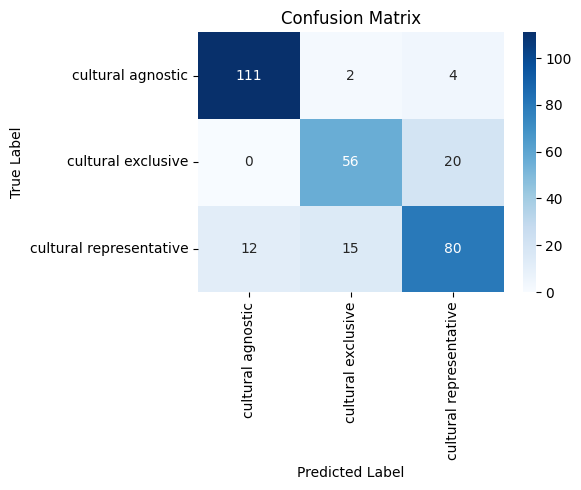

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

predictions = trainer.predict(val_ds_tokenized)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

labels = label_encoder.classes_

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [ ]:
# Zip the folder
!zip -r final_model.zip final_model
!zip -r cultural_classifier_model.zip cultural_classifier_model
from google.colab import files
files.download("final_model.zip")
files.download("cultural_classifier_model.zip") #no download because the runtime ended ಸ‿ಸ

  adding: final_model/ (stored 0%)
  adding: final_model/special_tokens_map.json (deflated 52%)
  adding: final_model/tokenizer_config.json (deflated 75%)
  adding: final_model/training_args.bin (deflated 52%)
  adding: final_model/config.json (deflated 52%)
  adding: final_model/tokenizer.json (deflated 82%)
  adding: final_model/model.safetensors (deflated 13%)
  adding: final_model/merges.txt (deflated 53%)
  adding: final_model/vocab.json (deflated 59%)
  adding: cultural_classifier_model/ (stored 0%)
  adding: cultural_classifier_model/checkpoint-1173/ (stored 0%)
  adding: cultural_classifier_model/checkpoint-1173/special_tokens_map.json (deflated 52%)
  adding: cultural_classifier_model/checkpoint-1173/trainer_state.json (deflated 67%)
  adding: cultural_classifier_model/checkpoint-1173/tokenizer_config.json (deflated 75%)
  adding: cultural_classifier_model/checkpoint-1173/training_args.bin (deflated 52%)
  adding: cultural_classifier_model/checkpoint-1173/config.json (deflated

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>